In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

In [3]:
train_data = pd.read_csv('/content/Train (1).csv')
print("Shape of train_data:", train_data.shape)

X = train_data.iloc[:, 1:]
y = train_data.iloc[:, 0]

print("Shape of X after separating features:", X.shape)

Shape of train_data: (42000, 785)
Shape of X after separating features: (42000, 784)


In [4]:
# ensure X is inthe correct format(Pandas DataFrame)
if not isinstance(X, pd.DataFrame):
    X = pd.DataFrame(X)
# Convert all pixel values to numeric format and replace any missing values with 0
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# Normalize the pixel values to the range [0, 1] by dividing them by 255.0. This helps the model learm faster.
X = X.values / 255.0

# Finally we reshape the data to include a channel dimension making it compatible with neural networks
X = X.reshape(-1, 28, 28, 1)
print("Shape of X after reshaping:", X.shape)

Shape of X after reshaping: (42000, 28, 28, 1)


In [12]:
# One-Hot Encode the Labels
y = train_data.iloc[:, 0] # Re-extract original labels to ensure correct shape
y = to_categorical(y, num_classes=10)
print("Shape of y after one-hot encoding:", y.shape)

Shape of y after one-hot encoding: (42000, 10)


In [13]:
# Split the data into train-test
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)

Shape of X_train: (33600, 28, 28, 1)
Shape of y_train: (33600, 10)


A Flatten layer converts the 28x28 image into a single vector of length 784.

Two hidden layers with 128 and 64 neurons use the ReLU activation function to introduce non-linearity.

An output layer with 10 neurons uses the softmax activation function to predict probabilities for each digit (0-9).

We compile the model with the Adam optimizer, categorical cross-entropy loss, and accuracy as the evaluation metric.

In [14]:
model = Sequential()
model.add(Flatten(input_shape=(28, 28, 1)))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = model.fit(X_train,
                    y_train,
                    epochs=10,
                    batch_size=32,
                    validation_data=(X_val, y_val)
                    )

Epoch 1/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9090 - loss: 0.3093 - val_accuracy: 0.9488 - val_loss: 0.1723
Epoch 2/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9602 - loss: 0.1303 - val_accuracy: 0.9596 - val_loss: 0.1351
Epoch 3/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9722 - loss: 0.0902 - val_accuracy: 0.9636 - val_loss: 0.1216
Epoch 4/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9786 - loss: 0.0672 - val_accuracy: 0.9686 - val_loss: 0.0996
Epoch 5/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9836 - loss: 0.0516 - val_accuracy: 0.9683 - val_loss: 0.1112
Epoch 6/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9863 - loss: 0.0405 - val_accuracy: 0.9675 - val_loss: 0.1095
Epoch 7/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9894 - loss: 0.0326 - val_accuracy: 0.9708 - val_loss: 0.1019
Epoch 8/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9913 - loss: 0.0268 - 

In [16]:
history.history

{'accuracy': [0.9089583158493042,
  0.9602380990982056,
  0.9722023606300354,
  0.9786012172698975,
  0.9836012125015259,
  0.986339271068573,
  0.9893749952316284,
  0.9913392663002014,
  0.9923809766769409,
  0.9942559599876404],
 'loss': [0.3093276023864746,
  0.1303432583808899,
  0.09017937630414963,
  0.06721220165491104,
  0.05160582438111305,
  0.04047411307692528,
  0.03256719931960106,
  0.02682754024863243,
  0.021406127139925957,
  0.017680106684565544],
 'val_accuracy': [0.9488095045089722,
  0.9596428275108337,
  0.9635714292526245,
  0.9685714244842529,
  0.9683333039283752,
  0.9674999713897705,
  0.9708333611488342,
  0.9682142734527588,
  0.9715476036071777,
  0.9705952405929565],
 'val_loss': [0.17232558131217957,
  0.13510191440582275,
  0.12161503732204437,
  0.09959429502487183,
  0.11117731779813766,
  0.10945505648851395,
  0.1018669456243515,
  0.12220901995897293,
  0.10548000782728195,
  0.11014028638601303]}

In [17]:
val_loss, val_acc = model.evaluate(X_val, y_val)
print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_acc)

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9706 - loss: 0.1101
Validation Loss: 0.11014028638601303
Validation Accuracy: 0.9705952405929565


In [18]:
print(f"Validation Accuracy: {val_acc * 100:.2f}%")

Validation Accuracy: 97.06%


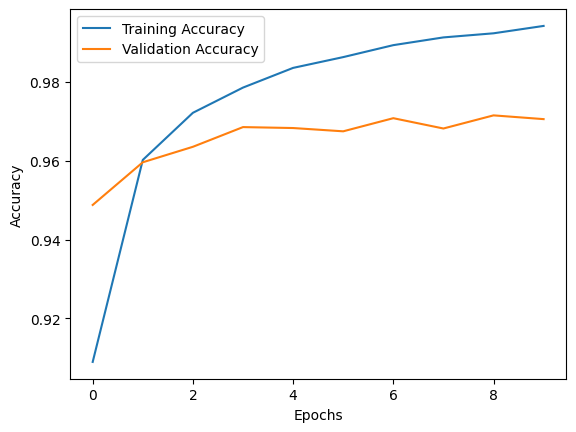

In [19]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

The blue line represents the training accuracy which consistently increases over the training steps while the orange line represents the validation accuracy which fluctuates slightly but shows a positive trend. By the end of the training the model achieves a training accuracy of around 96.81% and a validation accuracy of 97.13% indicating the model performs well on both training and validation data suggesting good generalization capability.

175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


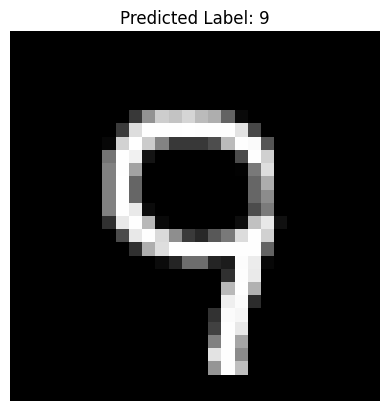

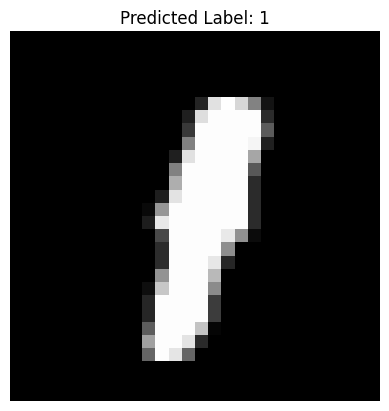

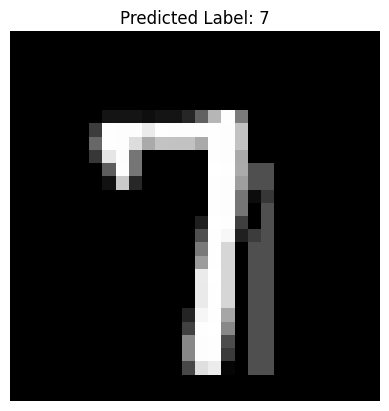

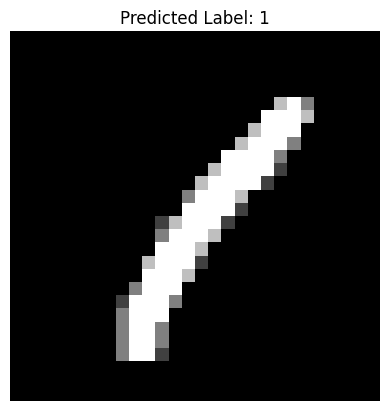

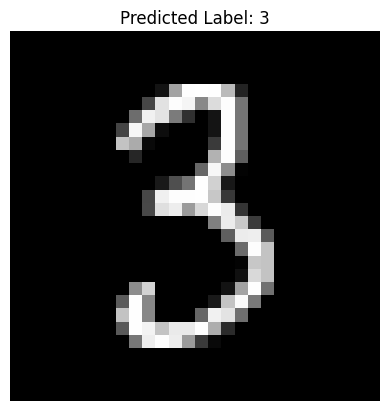

In [20]:
test_data = pd.read_csv('/content/test.csv')
X_test = test_data.values / 255.0
X_test = X_test.reshape(-1, 28, 28, 1)
predictions = model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)
for i in range(5):
  plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
  plt.title(f"Predicted Label: {predicted_labels[i]}")
  plt.axis('off')
  plt.show()